# Procurement Invoice Fraud Dataset — Full EDA & Class Balance Analysis

This notebook picks up from your loading template and does a complete first-pass analysis:

1. Setup & data loading (same as your template)
2. Dataset overview (shape, dtypes, nulls, duplicates, uniques) for every table
3. Merge all tables into one master dataframe
4. **Class balance analysis** — overall, by fraud type, and by train/val/test split
5. Numeric feature analysis (distributions, outliers, group stats by fraud label)
6. Categorical / flag feature analysis (fraud rate per category)
7. Correlation analysis
8. Time-based analysis (if a date column exists)
9. Summary + recommendations for modeling on an imbalanced dataset

Run cells top to bottom. Everything after the "Load Data" section is generic — it auto-detects
column types, so it will keep working even if the exact `invoices` schema differs slightly from
what's assumed here.

## 1. Setup & Imports

In [ ]:
!pip install pyarrow fastparquet -q

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 150)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

RANDOM_STATE = 42

## 2. Load Data

In [ ]:
ZIP_PATH = "/content/drive/MyDrive/ML_Project_CDAC/archive (6).zip"
EXTRACT_PATH = "/content/procurement_fraud_dataset"

if not os.path.exists(EXTRACT_PATH):
    print("Extracting ZIP file...")
    with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall(EXTRACT_PATH)
    print("Extraction completed.")
else:
    print("Dataset already extracted.")

Dataset already extracted.


In [ ]:
parquet_files = list(Path(EXTRACT_PATH).rglob("*.parquet"))
print("Total Parquet Files:", len(parquet_files))
for f in parquet_files:
    print(" -", f)

Total Parquet Files: 7
 - /content/procurement_fraud_dataset/Procument Invoice Fraud Dataset v1/suppliers.parquet
 - /content/procurement_fraud_dataset/Procument Invoice Fraud Dataset v1/departments.parquet
 - /content/procurement_fraud_dataset/Procument Invoice Fraud Dataset v1/labels.parquet
 - /content/procurement_fraud_dataset/Procument Invoice Fraud Dataset v1/invoices.parquet
 - /content/procurement_fraud_dataset/Procument Invoice Fraud Dataset v1/images_metadata.parquet
 - /content/procurement_fraud_dataset/Procument Invoice Fraud Dataset v1/behavioural_features.parquet
 - /content/procurement_fraud_dataset/Procument Invoice Fraud Dataset v1/splits.parquet


In [ ]:
dataframes = {}
for file in parquet_files:
    name = file.stem
    dataframes[name] = pd.read_parquet(file)
    print(f"Loaded '{name}': {dataframes[name].shape}")

print("\nAvailable tables:", list(dataframes.keys()))

Loaded 'suppliers': (2000, 6)
Loaded 'departments': (50, 3)
Loaded 'labels': (300000, 5)
Loaded 'invoices': (300000, 10)
Loaded 'images_metadata': (45000, 4)
Loaded 'behavioural_features': (300000, 7)
Loaded 'splits': (300000, 2)

Available tables: ['suppliers', 'departments', 'labels', 'invoices', 'images_metadata', 'behavioural_features', 'splits']


## 3. Dataset Overview (all tables)

A reusable profiling function so you get the same consistent report for every table
(shape, dtypes, missing values, duplicate rows, unique counts, and a preview).

In [ ]:
def profile_dataframe(df, name):
    print("=" * 100)
    print("DATASET:", name)
    print("=" * 100)

    print(f"\nShape: {df.shape[0]:,} rows x {df.shape[1]} columns")

    print("\nColumn dtypes:")
    print(df.dtypes)

    print("\nMissing values (count / %):")
    miss = df.isnull().sum()
    miss_pct = (miss / len(df) * 100).round(2)
    miss_df = pd.DataFrame({"missing_count": miss, "missing_pct": miss_pct})
    print(miss_df[miss_df["missing_count"] > 0].sort_values("missing_count", ascending=False)
          if miss.sum() > 0 else "  none")

    print(f"\nDuplicate rows: {df.duplicated().sum():,}")

    print("\nUnique value counts per column:")
    print(df.nunique())

    print("\nPreview:")
    display(df.head())
    print("\n")


for name, df in dataframes.items():
    profile_dataframe(df, name)

DATASET: suppliers

Shape: 2,000 rows x 6 columns

Column dtypes:
supplier_id             object
supplier_country        object
supplier_age_days        int64
supplier_risk_score    float64
blacklisted_flag         int64
avg_invoice_amount     float64
dtype: object

Missing values (count / %):
  none

Duplicate rows: 0

Unique value counts per column:
supplier_id            2000
supplier_country        126
supplier_age_days      1564
supplier_risk_score     597
blacklisted_flag          2
avg_invoice_amount     1999
dtype: int64

Preview:


,supplier_id,supplier_country,supplier_age_days,supplier_risk_score,blacklisted_flag,avg_invoice_amount
0,fc3e058b-e0f3-4ab0-9cec-4eb5edd96831,SV,841,0.244,0,5590.25
1,3d4cbf37-4eb9-4eff-8e88-cb2dd4e80839,KE,61,0.284,0,5797.64
2,913e4de2-e0c5-4cb8-bda9-c2a90ed42f1a,YE,197,0.390,0,897.65
3,bb5e4bcf-15ed-4269-9429-6c07f26b4776,SA,851,0.299,0,7727.71
4,fa5d3100-11b7-4948-90e6-e6607c69dee1,DJ,4373,0.418,0,5458.67




DATASET: departments

Shape: 50 rows x 3 columns

Column dtypes:
department_id     object
region            object
annual_budget    float64
dtype: object

Missing values (count / %):
  none

Duplicate rows: 0

Unique value counts per column:
department_id    50
region           24
annual_budget    50
dtype: int64

Preview:


,department_id,region,annual_budget
0,DPT_000,Rhode Island,3.278881e+08
1,DPT_001,Arkansas,2.666879e+07
2,DPT_002,Nevada,1.491465e+07
3,DPT_003,New York,4.204102e+08
4,DPT_004,Louisiana,2.956358e+08




DATASET: labels

Shape: 300,000 rows x 5 columns

Column dtypes:
invoice_id      object
is_fraud         int64
fraud_type      object
fraud_tags      object
explanations    object
dtype: object

Missing values (count / %):
  none

Duplicate rows: 0

Unique value counts per column:
invoice_id      300000
is_fraud             2
fraud_type           6
fraud_tags          16
explanations        16
dtype: int64

Preview:


...

,invoice_id,image_path,ocr_total_extracted,image_tamper_flag
0,INV_0004941,data/v1/20251214_172643/images/INV_0004941.png,52538.04,0
1,INV_0051775,data/v1/20251214_172643/images/INV_0051775.png,125344.24,0
2,INV_0115253,data/v1/20251214_172643/images/INV_0115253.png,63871.29,0
3,INV_0299321,data/v1/20251214_172643/images/INV_0299321.png,6622.06,0
4,INV_0173570,data/v1/20251214_172643/images/INV_0173570.png,23200.69,0




DATASET: behavioural_features

Shape: 300,000 rows x 7 columns

Column dtypes:
invoice_id                     object
supplier_invoice_count_30d    float64
supplier_avg_amount_90d       float64
invoice_amount_zscore         float64
duplicate_invoice_flag          int64
split_invoice_flag              int64
late_night_submission_flag      int64
dtype: object

Missing values (count / %):
  none

Duplicate rows: 0

Unique value counts per column:
invoice_id                    300000
supplier_invoice_count_30d        31
supplier_avg_amount_90d       299870
invoice_amount_zscore         268614
duplicate_invoice_flag             2
split_invoice_flag                 2
late_night_submission_flag         2
dtype: int64

Preview:


,invoice_id,supplier_invoice_count_30d,supplier_avg_amount_90d,invoice_amount_zscore,duplicate_invoice_flag,split_invoice_flag,late_night_submission_flag
0,INV_0138003,1.0,4252.160000,-0.375908,0,0,0
1,INV_0153155,2.0,13972.275000,1.830169,0,0,0
2,INV_0034829,3.0,17737.206667,2.008863,0,0,0
3,INV_0072998,4.0,14480.340000,-0.323982,0,1,0
4,INV_0211525,5.0,12515.048000,-0.330321,0,1,0




DATASET: splits

Shape: 300,000 rows x 2 columns

Column dtypes:
invoice_id    object
split         object
dtype: object

Missing values (count / %):
  none

Duplicate rows: 0

Unique value counts per column:
invoice_id    300000
split              3
dtype: int64

Preview:


,invoice_id,split
0,INV_0258729,train
1,INV_0179434,train
2,INV_0123072,train
3,INV_0031388,train
4,INV_0205955,train


In [ ]:
# How do the tables relate to each other? (shared key columns)
names = list(dataframes.keys())
print("Shared columns between tables (likely join keys):\n")
for i in range(len(names)):
    for j in range(i + 1, len(names)):
        common = set(dataframes[names[i]].columns) & set(dataframes[names[j]].columns)
        if common:
            print(f"{names[i]}  <-->  {names[j]}  :  {common}")

Shared columns between tables (likely join keys):

suppliers  <-->  invoices  :  {'supplier_id'}
departments  <-->  invoices  :  {'department_id'}
labels  <-->  invoices  :  {'invoice_id'}
labels  <-->  images_metadata  :  {'invoice_id'}
labels  <-->  behavioural_features  :  {'invoice_id'}
labels  <-->  splits  :  {'invoice_id'}
invoices  <-->  images_metadata  :  {'invoice_id', 'image_path'}
invoices  <-->  behavioural_features  :  {'invoice_id'}
invoices  <-->  splits  :  {'invoice_id'}
images_metadata  <-->  behavioural_features  :  {'invoice_id'}
images_metadata  <-->  splits  :  {'invoice_id'}
behavioural_features  <-->  splits  :  {'invoice_id'}


## 4. Build a Master Dataframe

Merge everything onto `invoice_id` so every downstream analysis has full context
(invoice details + behavioural features + label + split) in a single table.
Adjust the join keys below if your table names/columns differ.

In [ ]:
labels = dataframes.get("labels")
invoices = dataframes.get("invoices")
behavioural = dataframes.get("behavioural_features")
splits = dataframes.get("splits")

TARGET = "is_fraud"          # binary fraud flag
FRAUD_TYPE_COL = "fraud_type"  # multi-class fraud category (NaN/"none" for legit invoices)
KEY = "invoice_id"

master = invoices.copy()

for extra_name, extra_df in [("behavioural_features", behavioural),
                              ("labels", labels),
                              ("splits", splits)]:
    if extra_df is not None and KEY in extra_df.columns:
        overlap = (set(master.columns) & set(extra_df.columns)) - {KEY}
        master = master.merge(
            extra_df.drop(columns=list(overlap), errors="ignore"),
            on=KEY, how="left"
        )
        print(f"Merged {extra_name} -> master shape: {master.shape}")

print("\nFinal master shape:", master.shape)
display(master.head())

Merged behavioural_features -> master shape: (300000, 16)
Merged labels -> master shape: (300000, 20)
Merged splits -> master shape: (300000, 21)

Final master shape: (300000, 21)


,invoice_id,supplier_id,department_id,invoice_date,invoice_amount,currency,payment_terms,invoice_type,submission_hour,image_path,supplier_invoice_count_30d,supplier_avg_amount_90d,invoice_amount_zscore,duplicate_invoice_flag,split_invoice_flag,late_night_submission_flag,is_fraud,fraud_type,fraud_tags,explanations,split
0,INV_0000000,7316ce64-2a14-4a96-9b0c-62eb27c8fc6c,DPT_025,2023-04-18,3565.57,ZAR,NET60,GOODS,18,data/v1/20251214_172643/images/INV_0000000.png,13.0,5417.982105,-0.453822,0,0,0,0,NONE,,"{""reason"": ""NONE""}",train
1,INV_0000001,7428a656-b3ee-4d3b-9a10-412954aebd1b,DPT_010,2023-10-08,9871.78,ZAR,NET30,SERVICES,6,None,6.0,6745.242333,0.261806,0,0,0,0,NONE,,"{""reason"": ""NONE""}",val
2,INV_0000002,7b0ccad9-eee1-4cae-b02e-21aa352b6ec8,DPT_041,2023-09-24,8530.64,ZAR,NET60,SERVICES,23,None,13.0,4950.948095,0.109614,0,0,0,0,NONE,,"{""reason"": ""NONE""}",val
3,INV_0000003,1c6345ab-6e0e-41e8-985d-3f861d2324e6,DPT_015,2023-10-15,1378.52,ZAR,NET30,GOODS,7,None,15.0,3524.075116,-0.702008,0,1,0,1,SPLIT,SPLIT,"{""rules"": [""SPLIT""]}",val
4,INV_0000004,22d839d3-33e4-4986-b18c-ccdc131eb723,DPT_039,2023-06-07,2373.66,ZAR,NET30,GOODS,12,None,11.0,4670.320968,-0.589080,0,0,0,0,NONE,,"{""reason"": ""NONE""}",train


## 5. Class Balance Analysis

This is the core question: **how imbalanced is this dataset?** Fraud datasets are almost
always heavily skewed toward the negative class, which affects everything downstream —
metric choice, resampling strategy, and how you interpret model performance.

In [ ]:
fraud_counts = labels[TARGET].value_counts().sort_index()
fraud_pct = (labels[TARGET].value_counts(normalize=True).sort_index() * 100).round(3)

balance_summary = pd.DataFrame({"count": fraud_counts, "percentage": fraud_pct})
print("Overall class balance:")
display(balance_summary)

majority = fraud_counts.max()
minority = fraud_counts.min()
print(f"\nImbalance ratio (majority:minority)  ->  {majority/minority:.1f} : 1")
print(f"Minority class share -> {fraud_pct.min():.2f}%")

Overall class balance:


,count,percentage
is_fraud,,
0,233590,77.863
1,66410,22.137



Imbalance ratio (majority:minority)  ->  3.5 : 1
Minority class share -> 22.14%


/tmp/ipykernel_6380/2733963513.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=labels[TARGET].astype(str), ax=axes[0], palette="Set2")


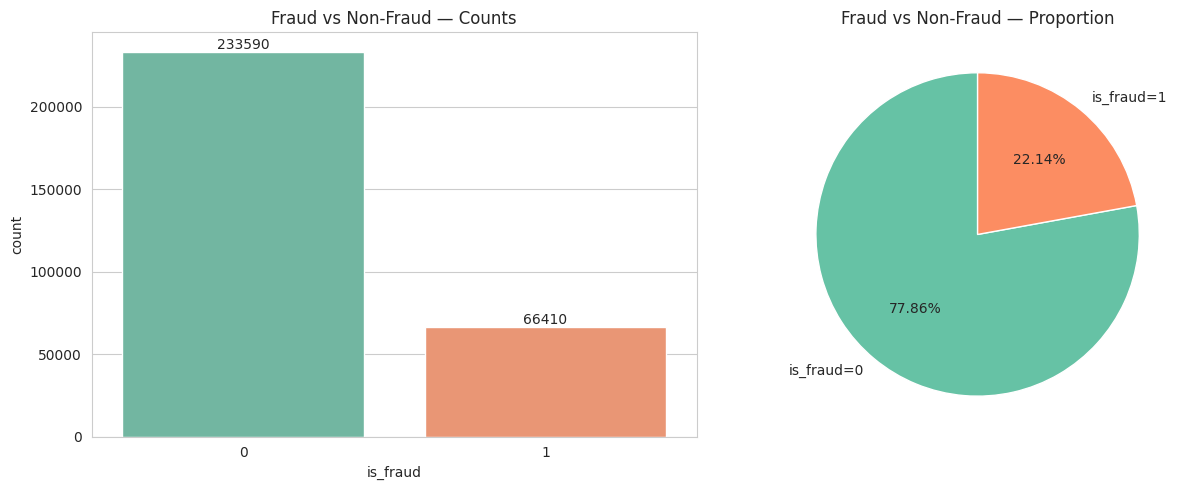

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.countplot(x=labels[TARGET].astype(str), ax=axes[0], palette="Set2")
axes[0].set_title("Fraud vs Non-Fraud — Counts")
axes[0].set_xlabel(TARGET)
for container in axes[0].containers:
    axes[0].bar_label(container)

axes[1].pie(fraud_counts, labels=[f"{TARGET}={i}" for i in fraud_counts.index],
            autopct="%1.2f%%", startangle=90, colors=sns.color_palette("Set2"))
axes[1].set_title("Fraud vs Non-Fraud — Proportion")

plt.tight_layout()
plt.show()

Fraud type distribution:


,count,percentage
fraud_type,,
NONE,237036,79.01
SPLIT,42346,14.12
GHOST_SUPPLIER,12588,4.20
INFLATED,5581,1.86
DOC_TAMPER,2379,0.79
DUPLICATE,70,0.02


/tmp/ipykernel_6380/133086683.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ft_counts.values, y=order.astype(str), palette="viridis")


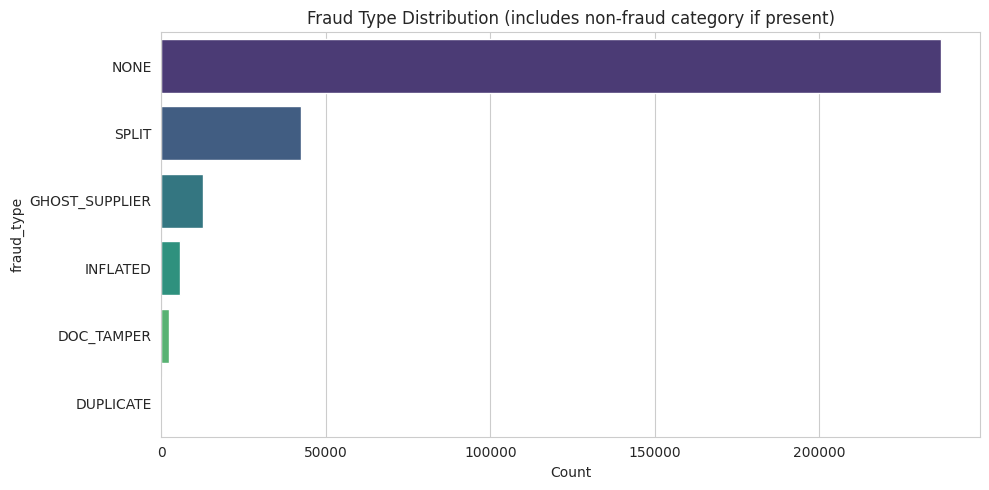


fraud_type vs is_fraud crosstab:


is_fraud,0,1
fraud_type,,
DOC_TAMPER,49,2330
DUPLICATE,0,70
GHOST_SUPPLIER,244,12344
INFLATED,115,5466
NONE,232313,4723
SPLIT,869,41477


In [ ]:
if FRAUD_TYPE_COL in labels.columns:
    ft_counts = labels[FRAUD_TYPE_COL].value_counts(dropna=False)
    ft_pct = (labels[FRAUD_TYPE_COL].value_counts(normalize=True, dropna=False) * 100).round(2)
    print("Fraud type distribution:")
    display(pd.DataFrame({"count": ft_counts, "percentage": ft_pct}))

    plt.figure(figsize=(10, 5))
    order = ft_counts.index
    sns.barplot(x=ft_counts.values, y=order.astype(str), palette="viridis")
    plt.title("Fraud Type Distribution (includes non-fraud category if present)")
    plt.xlabel("Count")
    plt.tight_layout()
    plt.show()

    print("\nfraud_type vs is_fraud crosstab:")
    display(pd.crosstab(labels[FRAUD_TYPE_COL], labels[TARGET]))

Counts by split:


is_fraud,0,1
split,,
test,46490,13510
train,163873,46127
val,23227,6773



Fraud rate (%) by split:


is_fraud,0,1
split,,
test,77.483,22.517
train,78.035,21.965
val,77.423,22.577


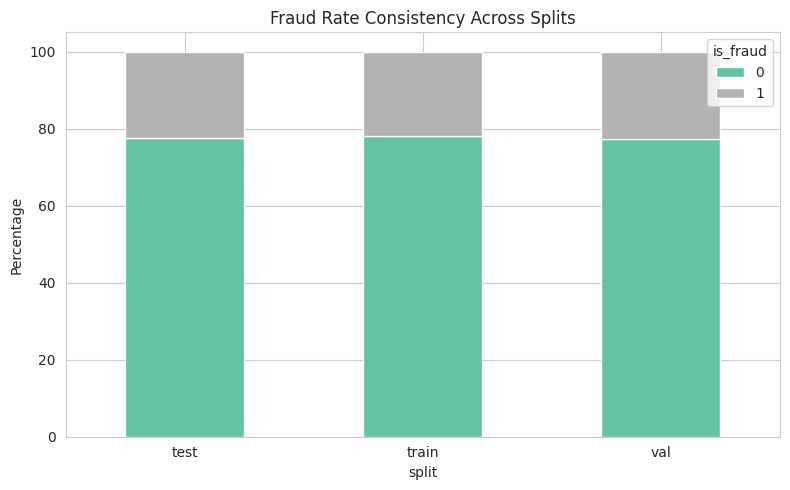

In [ ]:
# Is the imbalance consistent across train/val/test splits?
# (Important: stratified splits should preserve the same fraud rate in every split)
if splits is not None:
    labels_splits = labels.merge(splits, on=KEY, how="inner")

    split_counts = pd.crosstab(labels_splits["split"], labels_splits[TARGET])
    split_pct = pd.crosstab(labels_splits["split"], labels_splits[TARGET], normalize="index") * 100

    print("Counts by split:")
    display(split_counts)
    print("\nFraud rate (%) by split:")
    display(split_pct.round(3))

    split_pct.plot(kind="bar", stacked=True, figsize=(8, 5), colormap="Set2")
    plt.title("Fraud Rate Consistency Across Splits")
    plt.ylabel("Percentage")
    plt.xticks(rotation=0)
    plt.legend(title=TARGET)
    plt.tight_layout()
    plt.show()

## 6. Automatic Column Typing

Rather than hardcoding `invoices` column names (which may vary), classify every column
in `master` into: identifier, boolean/flag, numeric, categorical, or datetime — then run
the right analysis for each type automatically.

In [ ]:
EXCLUDE = {KEY, TARGET, FRAUD_TYPE_COL, "split"}
ID_LIKE_SUFFIXES = ("_id", "id")

id_cols, bool_cols, numeric_cols, categorical_cols, datetime_cols = [], [], [], [], []

for col in master.columns:
    if col in EXCLUDE:
        continue
    s = master[col]

    if pd.api.types.is_datetime64_any_dtype(s):
        datetime_cols.append(col)
    elif pd.api.types.is_bool_dtype(s) or sorted(s.dropna().unique().tolist()) in ([0, 1], [False, True]):
        bool_cols.append(col)
    elif col.lower().endswith(ID_LIKE_SUFFIXES) or s.nunique() == len(s):
        id_cols.append(col)
    elif pd.api.types.is_numeric_dtype(s):
        numeric_cols.append(col)
    elif s.dtype == object or pd.api.types.is_categorical_dtype(s):
        # attempt datetime parse for object columns that look like dates
        if "date" in col.lower() or "time" in col.lower():
            try:
                master[col] = pd.to_datetime(s)
                datetime_cols.append(col)
                continue
            except Exception:
                pass
        if s.nunique() <= 50:
            categorical_cols.append(col)
        else:
            id_cols.append(col)  # too many unique values, treat as identifier/free text

print("Identifier-like columns :", id_cols)
print("Boolean / flag columns  :", bool_cols)
print("Numeric columns         :", numeric_cols)
print("Categorical columns     :", categorical_cols)
print("Datetime columns        :", datetime_cols)

Identifier-like columns : ['supplier_id', 'department_id', 'image_path']
Boolean / flag columns  : ['duplicate_invoice_flag', 'split_invoice_flag', 'late_night_submission_flag']
Numeric columns         : ['invoice_amount', 'submission_hour', 'supplier_invoice_count_30d', 'supplier_avg_amount_90d', 'invoice_amount_zscore']
Categorical columns     : ['currency', 'payment_terms', 'invoice_type', 'fraud_tags', 'explanations']
Datetime columns        : ['invoice_date']


## 7. Numeric Feature Analysis

For every numeric feature: summary stats overall, grouped mean/median/std by fraud label,
distribution plots split by class, and boxplots to flag outliers.

In [ ]:
if numeric_cols:
    print("Overall numeric summary:")
    display(master[numeric_cols].describe().T)

    print("\nGrouped stats by is_fraud (mean / median / std):")
    display(master.groupby(TARGET)[numeric_cols].agg(["mean", "median", "std"]).T)

Overall numeric summary:


,count,mean,std,min,25%,50%,75%,max
invoice_amount,300000.0,7.564709e+03,8812.143358,37.350000,2641.757500,4892.300000,9166.187500,294048.720000
submission_hour,300000.0,1.148524e+01,6.922530,0.000000,5.000000,11.000000,17.000000,23.000000
supplier_invoice_count_30d,300000.0,1.263589e+01,3.918758,1.000000,10.000000,13.000000,15.000000,31.000000
supplier_avg_amount_90d,300000.0,7.572865e+03,6240.050468,193.330000,3654.072531,5767.308586,9358.080053,294048.720000
invoice_amount_zscore,300000.0,5.570655e-17,1.000002,-0.854204,-0.558656,-0.303265,0.181736,32.510194



Grouped stats by is_fraud (mean / median / std):


is_fraud                                     0             1
invoice_amount             mean    7427.770754   8046.373192
                           median  5452.505000   2925.380000
                           std     6230.531271  14627.172706
submission_hour            mean      11.559305     11.224710
                           median    12.000000     11.000000
                           std        6.906849      6.971208
supplier_invoice_count_30d mean      12.577572     12.841033
                           median    13.000000     13.000000
                           std        3.956060      3.777514
supplier_avg_amount_90d    mean    7123.042257   9155.066042
                           median  5619.929476   6349.010771
                           std     5327.196720   8536.097449
invoice_amount_zscore      mean      -0.015540      0.054659
                           median    -0.239693     -0.526471
                           std        0.707040      1.659891

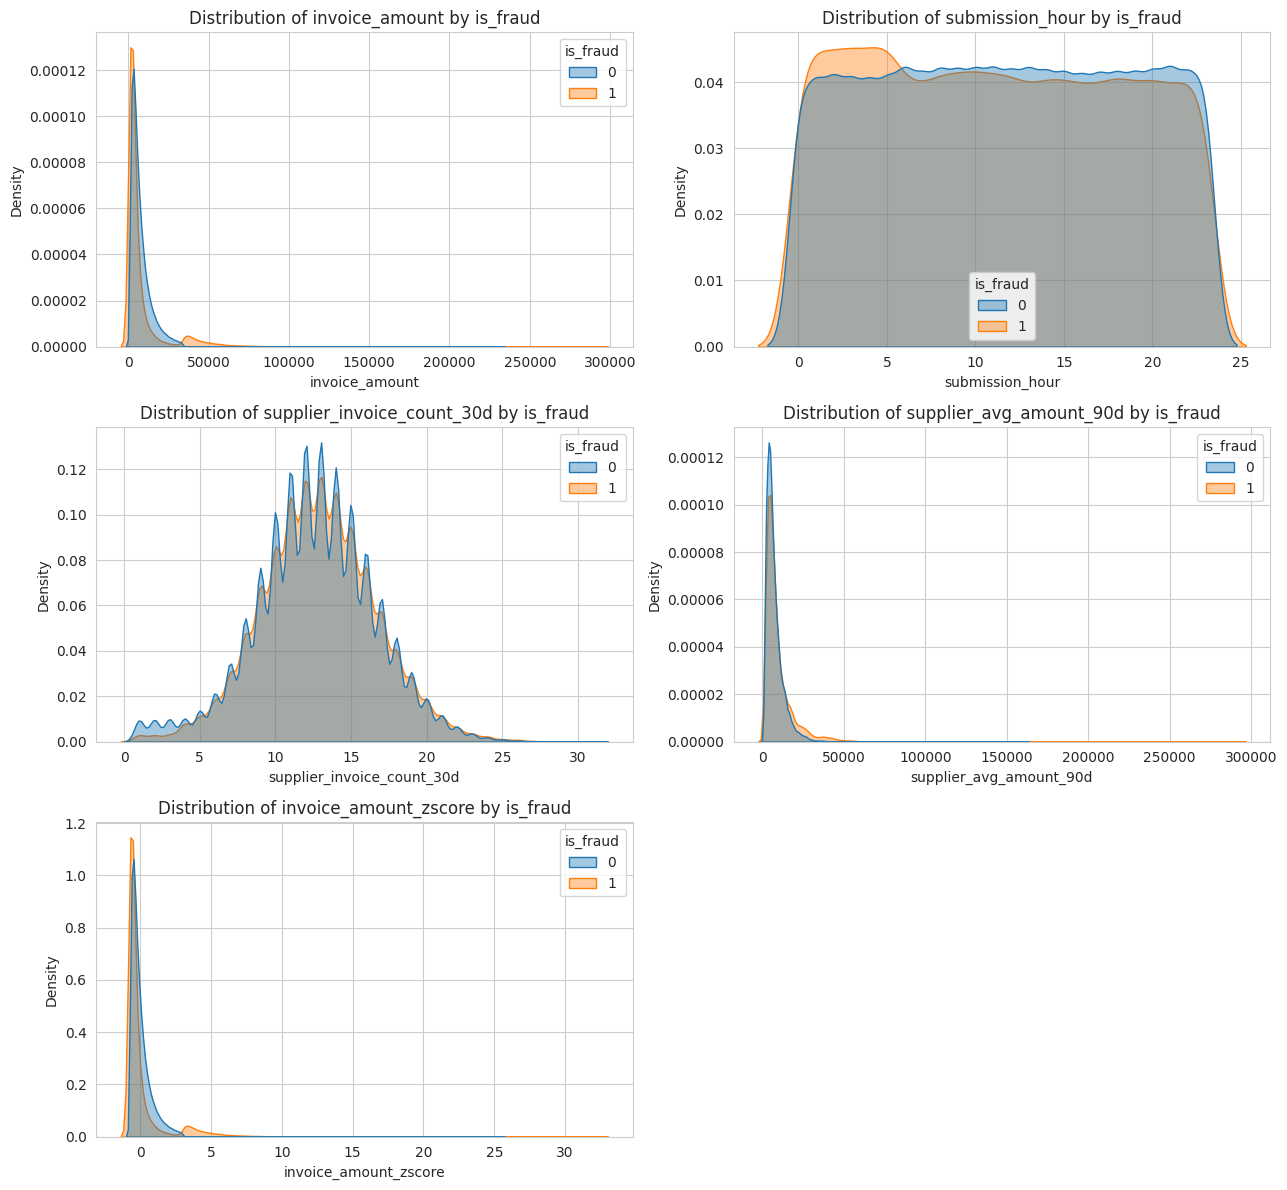

In [ ]:
n = len(numeric_cols)
if n:
    ncols = 2
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(13, 4 * nrows))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(numeric_cols):
        sns.kdeplot(data=master, x=col, hue=TARGET, common_norm=False, ax=axes[i], fill=True, alpha=0.4)
        axes[i].set_title(f"Distribution of {col} by {TARGET}")

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

/tmp/ipykernel_6380/3497167480.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=master, x=TARGET, y=col, ax=axes[i], palette="Set2")
/tmp/ipykernel_6380/3497167480.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=master, x=TARGET, y=col, ax=axes[i], palette="Set2")
/tmp/ipykernel_6380/3497167480.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=master, x=TARGET, y=col, ax=axes[i], palette="Set2")
/tmp/ipykernel_6380/3497167480.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be re

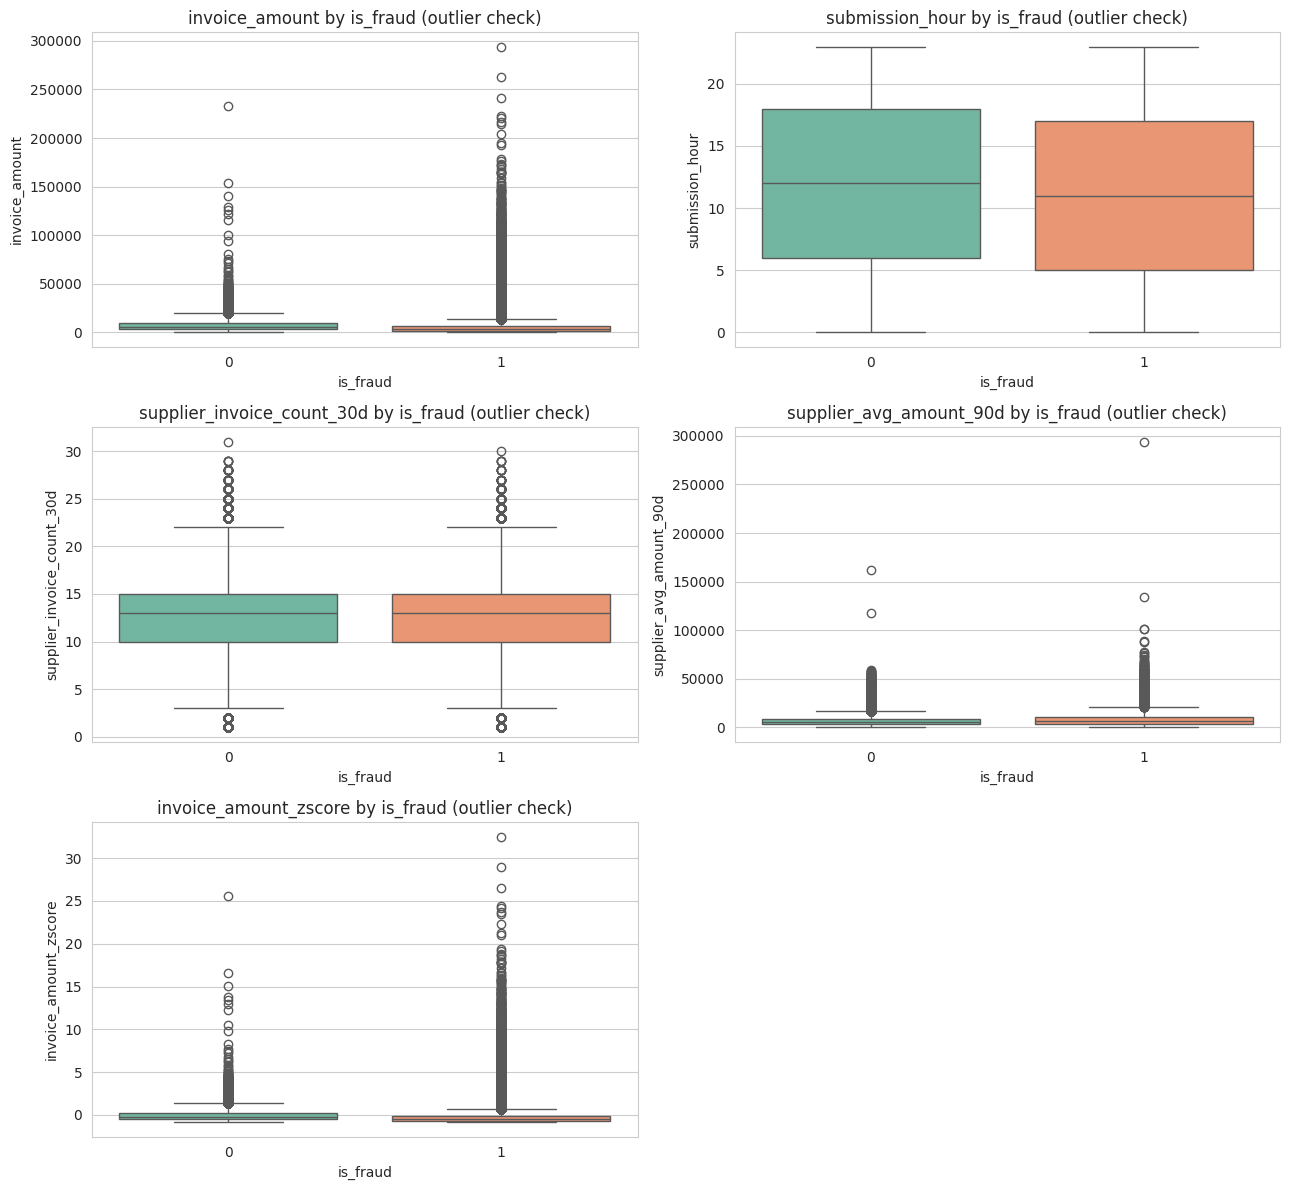

In [ ]:
if n:
    fig, axes = plt.subplots(nrows, ncols, figsize=(13, 4 * nrows))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(numeric_cols):
        sns.boxplot(data=master, x=TARGET, y=col, ax=axes[i], palette="Set2")
        axes[i].set_title(f"{col} by {TARGET} (outlier check)")

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

In [ ]:
# IQR-based outlier count per numeric column
outlier_summary = {}
for col in numeric_cols:
    q1, q3 = master[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((master[col] < lower) | (master[col] > upper)).sum()
    outlier_summary[col] = {"n_outliers": n_out, "pct_outliers": round(n_out / len(master) * 100, 2)}

display(pd.DataFrame(outlier_summary).T.sort_values("pct_outliers", ascending=False))

,n_outliers,pct_outliers
invoice_amount,22018.0,7.34
invoice_amount_zscore,22018.0,7.34
supplier_avg_amount_90d,18490.0,6.16
supplier_invoice_count_30d,5945.0,1.98
submission_hour,0.0,0.00


## 8. Categorical / Flag Feature Analysis

For every boolean flag and categorical column, look at the fraud rate within each category.
This is usually where the strongest fraud signals live (e.g. `late_night_submission_flag`,
`split_invoice_flag`, `duplicate_invoice_flag`).

In [ ]:
for col in bool_cols + categorical_cols:
    print("\n" + "=" * 70)
    print("FEATURE:", col)
    print("=" * 70)

    counts = pd.crosstab(master[col], master[TARGET])
    rates = pd.crosstab(master[col], master[TARGET], normalize="index") * 100
    display(counts)
    print("Fraud rate (%) within each category:")
    display(rates.round(2))


FEATURE: duplicate_invoice_flag


is_fraud,0,1
duplicate_invoice_flag,,
0,233590,66340
1,0,70


Fraud rate (%) within each category:


is_fraud,0,1
duplicate_invoice_flag,,
0,77.88,22.12
1,0.00,100.00



FEATURE: split_invoice_flag


...

is_fraud,0,1
fraud_tags,,
,98.01,1.99
DOC_TAMPER,1.81,98.19
DUPLICATE,0.00,100.00
DUPLICATE;GHOST_SUPPLIER,0.00,100.00
DUPLICATE;SPLIT,0.00,100.00
GHOST_SUPPLIER,1.94,98.06
GHOST_SUPPLIER;DOC_TAMPER,2.80,97.20
INFLATED,2.11,97.89
INFLATED;DOC_TAMPER,2.60,97.40



FEATURE: explanations


is_fraud,0,1
explanations,,
"{""reason"": ""NONE""}",232313,4723
"{""rules"": [""DOC_TAMPER""]}",33,1793
"{""rules"": [""DUPLICATE"", ""GHOST_SUPPLIER""]}",0,4
"{""rules"": [""DUPLICATE"", ""SPLIT""]}",0,8
"{""rules"": [""DUPLICATE""]}",0,58
"{""rules"": [""GHOST_SUPPLIER"", ""DOC_TAMPER""]}",4,139
"{""rules"": [""GHOST_SUPPLIER""]}",244,12344
"{""rules"": [""INFLATED"", ""DOC_TAMPER""]}",2,75
"{""rules"": [""INFLATED"", ""GHOST_SUPPLIER"", ""DOC_TAMPER""]}",0,8


Fraud rate (%) within each category:


is_fraud,0,1
explanations,,
"{""reason"": ""NONE""}",98.01,1.99
"{""rules"": [""DOC_TAMPER""]}",1.81,98.19
"{""rules"": [""DUPLICATE"", ""GHOST_SUPPLIER""]}",0.00,100.00
"{""rules"": [""DUPLICATE"", ""SPLIT""]}",0.00,100.00
"{""rules"": [""DUPLICATE""]}",0.00,100.00
"{""rules"": [""GHOST_SUPPLIER"", ""DOC_TAMPER""]}",2.80,97.20
"{""rules"": [""GHOST_SUPPLIER""]}",1.94,98.06
"{""rules"": [""INFLATED"", ""DOC_TAMPER""]}",2.60,97.40
"{""rules"": [""INFLATED"", ""GHOST_SUPPLIER"", ""DOC_TAMPER""]}",0.00,100.00


/tmp/ipykernel_6380/725310321.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rate.index.astype(str), y=rate.values, ax=axes[i], palette="rocket")
/tmp/ipykernel_6380/725310321.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rate.index.astype(str), y=rate.values, ax=axes[i], palette="rocket")
/tmp/ipykernel_6380/725310321.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rate.index.astype(str), y=rate.values, ax=axes[i], palette="rocket")
/tmp/ipykernel_6380/725310321.py:11: FutureWarning: 

Passing `palette` without assig

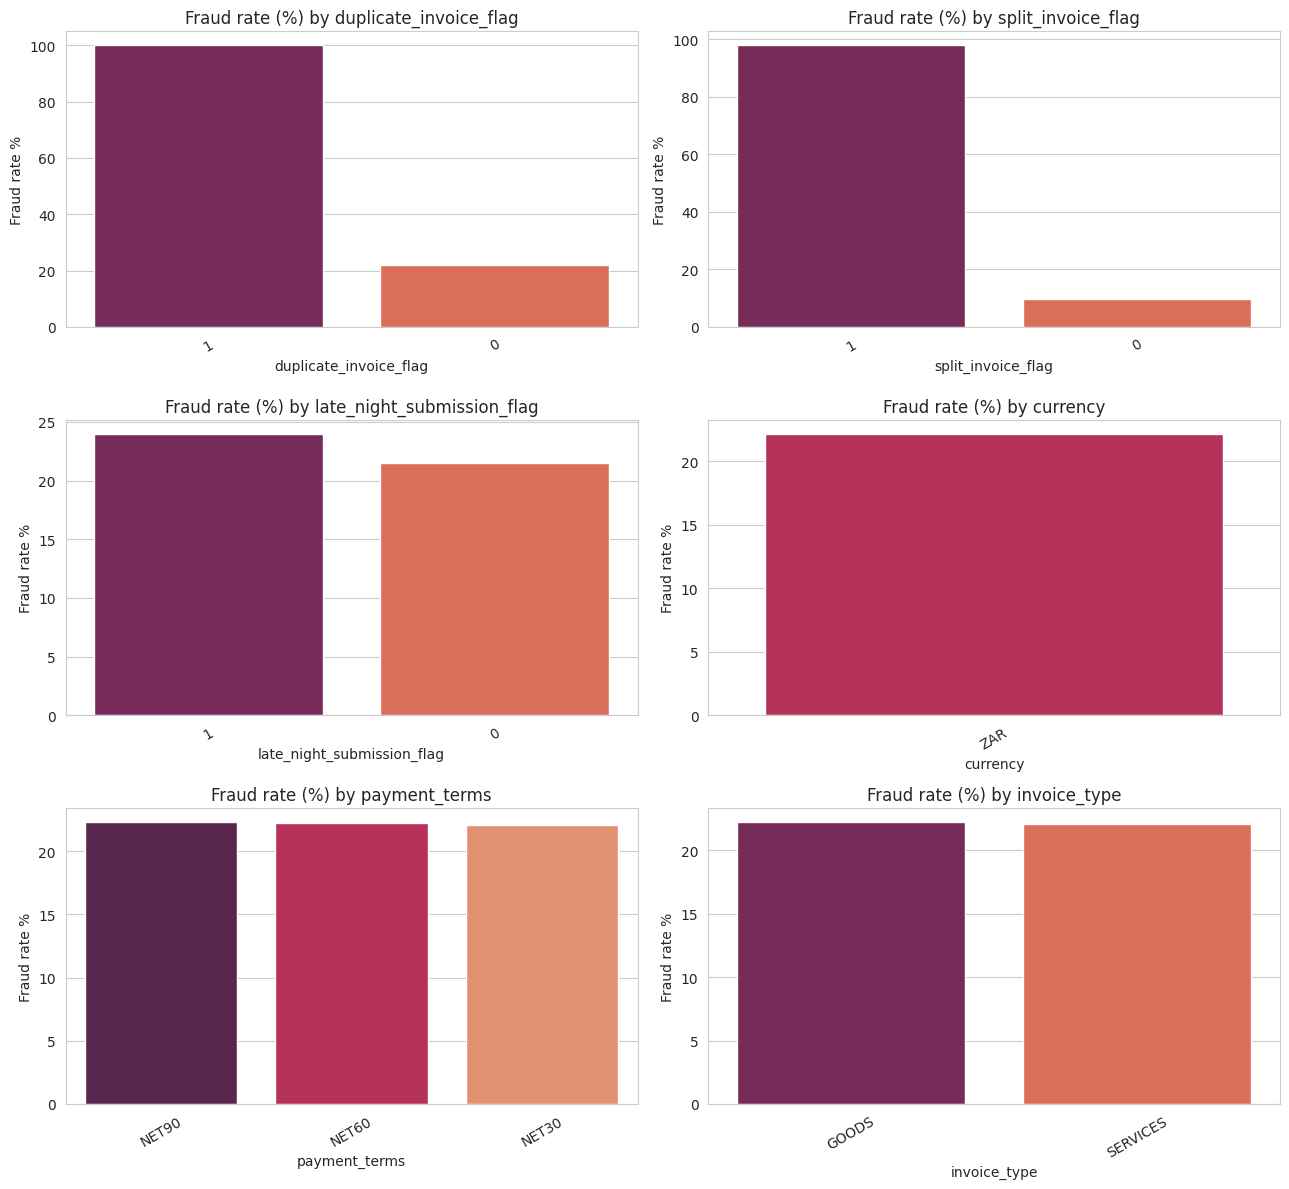

In [ ]:
cols_to_plot = bool_cols + [c for c in categorical_cols if master[c].nunique() <= 15]
n = len(cols_to_plot)
if n:
    ncols = 2
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(13, 4 * nrows))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(cols_to_plot):
        rate = master.groupby(col)[TARGET].mean().sort_values(ascending=False) * 100
        sns.barplot(x=rate.index.astype(str), y=rate.values, ax=axes[i], palette="rocket")
        axes[i].set_title(f"Fraud rate (%) by {col}")
        axes[i].set_ylabel("Fraud rate %")
        axes[i].tick_params(axis="x", rotation=30)

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

## 9. Correlation Analysis

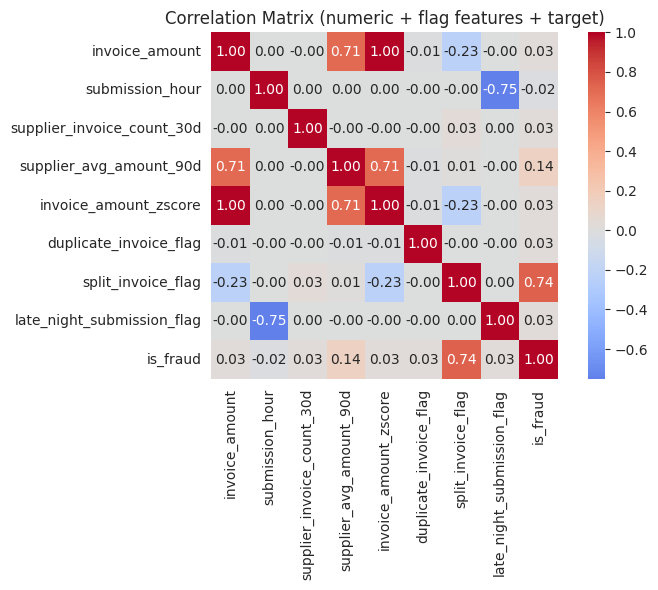


Correlation with target, sorted:
split_invoice_flag            0.743597
supplier_avg_amount_90d       0.135196
invoice_amount                0.029144
invoice_amount_zscore         0.029144
duplicate_invoice_flag        0.028652
supplier_invoice_count_30d    0.027912
late_night_submission_flag    0.025591
submission_hour              -0.020067
Name: is_fraud, dtype: float64


In [ ]:
corr_cols = numeric_cols + bool_cols + [TARGET]
corr_df = master[corr_cols].apply(pd.to_numeric, errors="coerce")
corr = corr_df.corr()

plt.figure(figsize=(max(8, len(corr_cols) * 0.6), max(6, len(corr_cols) * 0.5)))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation Matrix (numeric + flag features + target)")
plt.tight_layout()
plt.show()

print("\nCorrelation with target, sorted:")
print(corr[TARGET].drop(TARGET).sort_values(key=abs, ascending=False))

## 10. Time-Based Analysis (if a date/time column exists)

Fraud often clusters around specific times (e.g. late-night submissions, month-end,
end-of-quarter budget flushing). This only runs if a datetime column was detected.

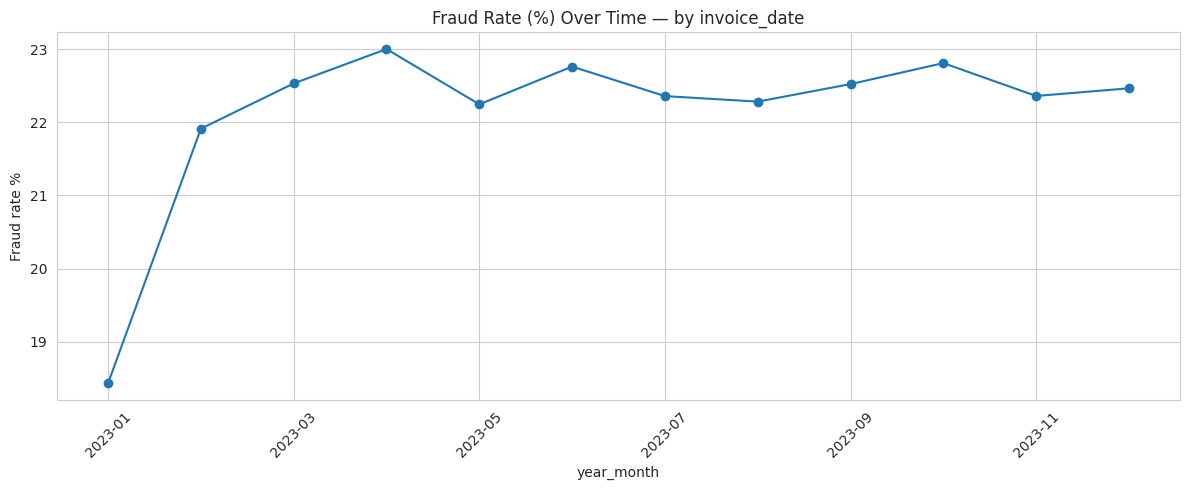

/tmp/ipykernel_6380/1722429445.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dow_rate.index, y=dow_rate.values, palette="mako")


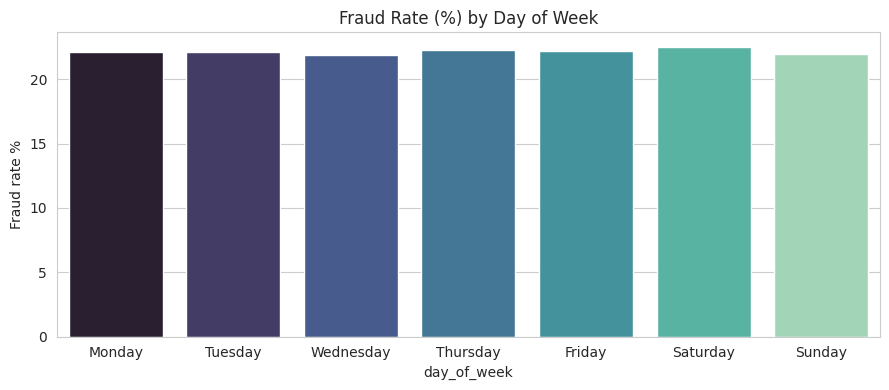

In [ ]:
if datetime_cols:
    date_col = datetime_cols[0]
    ts = master[[date_col, TARGET]].dropna().copy()
    ts["year_month"] = ts[date_col].dt.to_period("M").astype(str)
    ts["day_of_week"] = ts[date_col].dt.day_name()
    ts["hour"] = ts[date_col].dt.hour

    monthly_rate = ts.groupby("year_month")[TARGET].mean() * 100
    plt.figure(figsize=(12, 5))
    monthly_rate.plot(marker="o")
    plt.title(f"Fraud Rate (%) Over Time — by {date_col}")
    plt.ylabel("Fraud rate %")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    dow_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
    dow_rate = ts.groupby("day_of_week")[TARGET].mean().reindex(dow_order) * 100
    plt.figure(figsize=(9, 4))
    sns.barplot(x=dow_rate.index, y=dow_rate.values, palette="mako")
    plt.title("Fraud Rate (%) by Day of Week")
    plt.ylabel("Fraud rate %")
    plt.tight_layout()
    plt.show()

    if ts["hour"].nunique() > 1:
        hour_rate = ts.groupby("hour")[TARGET].mean() * 100
        plt.figure(figsize=(10, 4))
        sns.lineplot(x=hour_rate.index, y=hour_rate.values, marker="o")
        plt.title("Fraud Rate (%) by Hour of Day")
        plt.ylabel("Fraud rate %")
        plt.xlabel("Hour")
        plt.tight_layout()
        plt.show()
else:
    print("No datetime column detected in master — skipping time-based analysis.")

## 11. Summary & What This Means for Modeling

Run the cell below to auto-generate a short written summary from the numbers computed above.
Use this as your notes section before moving to feature engineering / modeling.

In [ ]:
minority_pct = fraud_pct.min()
imbalance_ratio = majority / minority

print("DATASET SUMMARY")
print("-" * 60)
print(f"Total invoices        : {len(labels):,}")
print(f"Fraud rate             : {minority_pct:.2f}%")
print(f"Imbalance ratio         : {imbalance_ratio:.1f} : 1  (majority:minority)")
if FRAUD_TYPE_COL in labels.columns:
    print(f"Distinct fraud types    : {labels[FRAUD_TYPE_COL].nunique()}")
print(f"Numeric features        : {len(numeric_cols)}")
print(f"Categorical/flag features: {len(bool_cols) + len(categorical_cols)}")
print(f"Missing values present  : {master.isnull().sum().sum() > 0}")

print("""
RECOMMENDATIONS FOR THIS LEVEL OF IMBALANCE:
- Do NOT use plain accuracy as your evaluation metric — a model predicting "no fraud"
  for everything would already score >{:.1f}% accuracy.
- Prefer PR-AUC, F1, recall, and a confusion matrix at your chosen threshold.
- Use the provided train/val/test `split` column (stratified) rather than re-splitting
  randomly, so the fraud rate stays consistent across sets.
- Consider class-weighting (class_weight='balanced') or resampling (SMOTE/undersampling)
  ONLY on the training fold — never on validation/test.
- Revisit the features with the strongest fraud-rate separation from Section 8/9 first;
  they're your best candidates for feature engineering and model interpretability (SHAP).
""".format(100 - minority_pct))

DATASET SUMMARY
------------------------------------------------------------
Total invoices        : 300,000
Fraud rate             : 22.14%
Imbalance ratio         : 3.5 : 1  (majority:minority)
Distinct fraud types    : 6
Numeric features        : 5
Categorical/flag features: 8
Missing values present  : True

RECOMMENDATIONS FOR THIS LEVEL OF IMBALANCE:
- Do NOT use plain accuracy as your evaluation metric — a model predicting "no fraud"
  for everything would already score >77.9% accuracy.
- Prefer PR-AUC, F1, recall, and a confusion matrix at your chosen threshold.
- Use the provided train/val/test `split` column (stratified) rather than re-splitting
  randomly, so the fraud rate stays consistent across sets.
- Consider class-weighting (class_weight='balanced') or resampling (SMOTE/undersampling)
  ONLY on the training fold — never on validation/test.
- Revisit the features with the strongest fraud-rate separation from Section 8/9 first;
  they're your best candidates for feature e

In [ ]:
for name, df in dataframes.items():
    print("\n" + "="*80)
    print(name.upper())
    print("="*80)
    display(pd.DataFrame({
        "Column": df.columns,
        "Data Type": df.dtypes.astype(str).values
    }))


SUPPLIERS


,Column,Data Type
0,supplier_id,object
1,supplier_country,object
2,supplier_age_days,int64
3,supplier_risk_score,float64
4,blacklisted_flag,int64
5,avg_invoice_amount,float64



DEPARTMENTS


,Column,Data Type
0,department_id,object
1,region,object
2,annual_budget,float64



LABELS


...

,Column,Data Type
0,invoice_id,object
1,image_path,object
2,ocr_total_extracted,float64
3,image_tamper_flag,int64



BEHAVIOURAL_FEATURES


,Column,Data Type
0,invoice_id,object
1,supplier_invoice_count_30d,float64
2,supplier_avg_amount_90d,float64
3,invoice_amount_zscore,float64
4,duplicate_invoice_flag,int64
5,split_invoice_flag,int64
6,late_night_submission_flag,int64



SPLITS


,Column,Data Type
0,invoice_id,object
1,split,object


In [ ]:
master = (
    dataframes["invoices"]
    .merge(dataframes["behavioural_features"], on="invoice_id", how="left")
    .merge(dataframes["labels"], on="invoice_id", how="left")
    .merge(dataframes["splits"], on="invoice_id", how="left")
    .merge(dataframes["suppliers"], on="supplier_id", how="left")
    .merge(dataframes["departments"], on="department_id", how="left")
)

print(master.shape)
master.head()

(300000, 28)


,invoice_id,supplier_id,department_id,invoice_date,invoice_amount,currency,payment_terms,invoice_type,submission_hour,image_path,supplier_invoice_count_30d,supplier_avg_amount_90d,invoice_amount_zscore,duplicate_invoice_flag,split_invoice_flag,late_night_submission_flag,is_fraud,fraud_type,fraud_tags,explanations,split,supplier_country,supplier_age_days,supplier_risk_score,blacklisted_flag,avg_invoice_amount,region,annual_budget
0,INV_0000000,7316ce64-2a14-4a96-9b0c-62eb27c8fc6c,DPT_025,2023-04-18,3565.57,ZAR,NET60,GOODS,18,data/v1/20251214_172643/images/INV_0000000.png,13.0,5417.982105,-0.453822,0,0,0,0,NONE,,"{""reason"": ""NONE""}",train,CA,1468,0.219,0,4552.54,North Carolina,2.171350e+07
1,INV_0000001,7428a656-b3ee-4d3b-9a10-412954aebd1b,DPT_010,2023-10-08,9871.78,ZAR,NET30,SERVICES,6,None,6.0,6745.242333,0.261806,0,0,0,0,NONE,,"{""reason"": ""NONE""}",val,SV,484,0.083,0,5568.13,Arizona,4.778807e+08
2,INV_0000002,7b0ccad9-eee1-4cae-b02e-21aa352b6ec8,DPT_041,2023-09-24,8530.64,ZAR,NET60,SERVICES,23,None,13.0,4950.948095,0.109614,0,0,0,0,NONE,,"{""reason"": ""NONE""}",val,MR,238,0.198,0,4542.37,Connecticut,5.119035e+07
3,INV_0000003,1c6345ab-6e0e-41e8-985d-3f861d2324e6,DPT_015,2023-10-15,1378.52,ZAR,NET30,GOODS,7,None,15.0,3524.075116,-0.702008,0,1,0,1,SPLIT,SPLIT,"{""rules"": [""SPLIT""]}",val,SR,2523,0.382,0,2705.89,Pennsylvania,7.018474e+06
4,INV_0000004,22d839d3-33e4-4986-b18c-ccdc131eb723,DPT_039,2023-06-07,2373.66,ZAR,NET30,GOODS,12,None,11.0,4670.320968,-0.589080,0,0,0,0,NONE,,"{""reason"": ""NONE""}",train,TV,153,0.139,0,3590.46,Louisiana,2.118290e+08


In [ ]:
master["invoice_id"].duplicated().sum()

np.int64(0)

In [ ]:
missing = master.isnull().sum().sort_values(ascending=False)
missing[missing > 0]

,0
image_path,255000


In [ ]:
master["split"].value_counts()

,count
split,
train,210000
test,60000
val,30000


In [ ]:
master["is_fraud"].value_counts()

,count
is_fraud,
0,233590
1,66410


In [ ]:
master["is_fraud"].value_counts(normalize=True) * 100

,proportion
is_fraud,
0,77.863333
1,22.136667


In [ ]:
print(master["supplier_id"].isna().sum())
print(master["department_id"].isna().sum())

0
0


In [ ]:
master["invoice_month"] = master["invoice_date"].dt.month
master["invoice_weekday"] = master["invoice_date"].dt.dayofweek
master["invoice_quarter"] = master["invoice_date"].dt.quarter
master["is_weekend"] = (master["invoice_weekday"] >= 5).astype(int)

In [ ]:
print("Shape:", master.shape)

master.info()

master.describe(include="all").T

Shape: (300000, 32)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 32 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   invoice_id                  300000 non-null  object        
 1   supplier_id                 300000 non-null  object        
 2   department_id               300000 non-null  object        
 3   invoice_date                300000 non-null  datetime64[ns]
 4   invoice_amount              300000 non-null  float64       
 5   currency                    300000 non-null  object        
 6   payment_terms               300000 non-null  object        
 7   invoice_type                300000 non-null  object        
 8   submission_hour             300000 non-null  int64         
 9   image_path                  45000 non-null   object        
 10  supplier_invoice_count_30d  300000 non-null  float64       
 11  supplier_avg_amount

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
invoice_id,300000,300000,INV_0299983,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
supplier_id,300000,2000,04aac1b7-5ca0-4428-822c-4d326c645c15,201,NaN,NaN,NaN,NaN,NaN,NaN,NaN
department_id,300000,50,DPT_013,6143,NaN,NaN,NaN,NaN,NaN,NaN,NaN
invoice_date,300000,NaN,NaN,NaN,2023-07-02 12:11:38.112000256,2023-01-01 00:00:00,2023-04-02 00:00:00,2023-07-03 00:00:00,2023-10-02 00:00:00,2023-12-31 00:00:00,NaN
invoice_amount,300000.0,NaN,NaN,NaN,7564.708713,37.35,2641.7575,4892.3,9166.1875,294048.72,8812.143358
currency,300000,1,ZAR,300000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
payment_terms,300000,3,NET30,180337,NaN,NaN,NaN,NaN,NaN,NaN,NaN
invoice_type,300000,2,GOODS,164863,NaN,NaN,NaN,NaN,NaN,NaN,NaN
submission_hour,300000.0,NaN,NaN,NaN,11.485237,0.0,5.0,11.0,17.0,23.0,6.92253
image_path,45000,45000,data/v1/20251214_172643/images/INV_0299983.png,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
missing = (
    master.isnull()
          .sum()
          .sort_values(ascending=False)
          .reset_index()
)

missing.columns = ["Column", "Missing Values"]
missing["Percentage"] = (missing["Missing Values"] / len(master)) * 100

missing

,Column,Missing Values,Percentage
0,image_path,255000,85.0
1,invoice_id,0,0.0
2,department_id,0,0.0
3,supplier_id,0,0.0
4,invoice_amount,0,0.0
5,currency,0,0.0
6,payment_terms,0,0.0
7,invoice_date,0,0.0
8,invoice_type,0,0.0
9,submission_hour,0,0.0


In [ ]:
print("Duplicate Rows :", master.duplicated().sum())
print("Duplicate Invoice IDs :", master["invoice_id"].duplicated().sum())

Duplicate Rows : 0
Duplicate Invoice IDs : 0


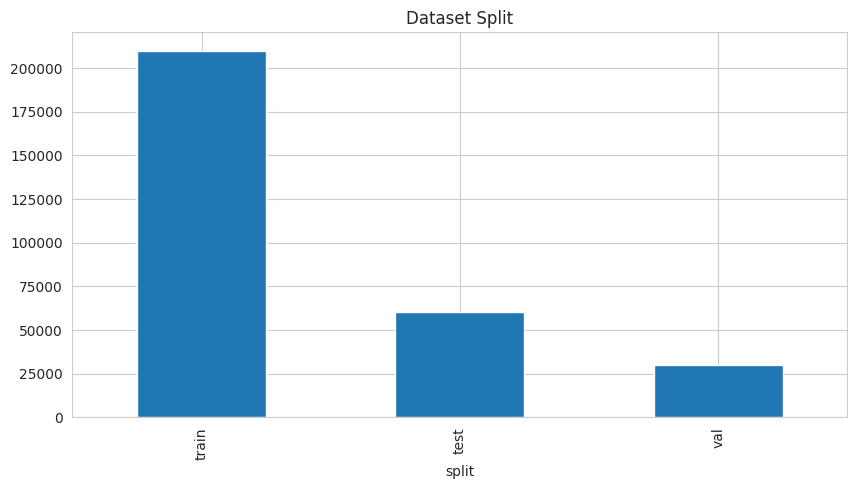

In [ ]:
master["split"].value_counts().plot(kind="bar")

plt.title("Dataset Split")
plt.show()

**Numerical Feature Summary**

In [ ]:
numeric_cols = master.select_dtypes(include=["int64", "float64"]).columns

master[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
invoice_amount,300000.0,7.564709e+03,8.812143e+03,3.735000e+01,2.641758e+03,4.892300e+03,9.166188e+03,2.940487e+05
submission_hour,300000.0,1.148524e+01,6.922530e+00,0.000000e+00,5.000000e+00,1.100000e+01,1.700000e+01,2.300000e+01
supplier_invoice_count_30d,300000.0,1.263589e+01,3.918758e+00,1.000000e+00,1.000000e+01,1.300000e+01,1.500000e+01,3.100000e+01
supplier_avg_amount_90d,300000.0,7.572865e+03,6.240050e+03,1.933300e+02,3.654073e+03,5.767309e+03,9.358080e+03,2.940487e+05
invoice_amount_zscore,300000.0,5.570655e-17,1.000002e+00,-8.542044e-01,-5.586563e-01,-3.032648e-01,1.817357e-01,3.251019e+01
duplicate_invoice_flag,300000.0,2.333333e-04,1.527350e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
split_invoice_flag,300000.0,1.422633e-01,3.493206e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
late_night_submission_flag,300000.0,2.505467e-01,4.333286e-01,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00
is_fraud,300000.0,2.213667e-01,4.151675e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
supplier_age_days,300000.0,2.259979e+03,1.567266e+03,3.000000e+01,8.040000e+02,2.243000e+03,3.629000e+03,4.999000e+03


**Categorical Feature Summary**

In [ ]:
categorical_cols = master.select_dtypes(include=["object"]).columns

for col in categorical_cols:
    print("="*50)
    print(col)
    print(master[col].value_counts().head(10))

invoice_id
invoice_id
INV_0299983    1
INV_0299982    1
INV_0299981    1
INV_0299980    1
INV_0299979    1
INV_0299978    1
INV_0299977    1
INV_0299976    1
INV_0299975    1
INV_0299974    1
Name: count, dtype: int64
supplier_id
supplier_id
04aac1b7-5ca0-4428-822c-4d326c645c15    201
65d0b517-88d0-4abd-8bb1-8c791036708d    193
61542765-d756-4a9c-864c-96479ea7017c    192
654c11d9-f2e6-4828-81bb-819c4dfe1117    191
d7665cda-fe04-4059-b985-fb6217dc8eff    190
65f202f9-83f0-4dc7-8f61-2217eef16694    189
3692a531-c609-4cd8-a127-dc6bab9b153d    187
9c81fc46-5bcd-436c-8777-4fae613758c3    186
82c299f0-7487-4772-bf03-86fa13badc91    184
67443fb8-81bd-45d5-b5a6-571c4fa5c35e    183
Name: count, dtype: int64
department_id
department_id
DPT_013    6143
DPT_009    6132
DPT_039    6103
DPT_036    6099
DPT_044    6097
DPT_030    6085
DPT_021    6081
DPT_043    6079
DPT_025    6072
DPT_019    6071
Name: count, dtype: int64
currency
currency
ZAR    300000
Name: count, dtype: int64
payment_terms
paymen

In [ ]:
drop_cols = [
    "invoice_id",
    "image_path",
    "fraud_type",
    "fraud_tags",
    "explanations"
]

master = master.drop(columns=drop_cols)

In [ ]:
master["department_id"].value_counts()

,count
department_id,
DPT_013,6143
DPT_009,6132
DPT_039,6103
DPT_036,6099
DPT_044,6097
DPT_030,6085
DPT_021,6081
DPT_043,6079
DPT_025,6072


In [ ]:
master.groupby("department_id")["is_fraud"].mean().sort_values(ascending=False)

,is_fraud
department_id,
DPT_014,0.231677
DPT_042,0.230782
DPT_002,0.228950
DPT_015,0.228835
DPT_034,0.227105
DPT_039,0.226446
DPT_044,0.226177
DPT_029,0.225681
DPT_043,0.225202


In [ ]:
master.groupby("department_id")["invoice_amount"].mean()

,invoice_amount
department_id,
DPT_000,7646.852532
DPT_001,7543.375424
DPT_002,7455.853952
DPT_003,7646.214705
DPT_004,7626.827036
DPT_005,7674.369221
DPT_006,7485.925595
DPT_007,7450.952564
DPT_008,7519.034505


In [ ]:
master.isnull().sum().sort_values(ascending=False)

,0
supplier_id,0
department_id,0
invoice_date,0
invoice_amount,0
currency,0
payment_terms,0
invoice_type,0
submission_hour,0
supplier_invoice_count_30d,0
supplier_avg_amount_90d,0


In [ ]:
drop_cols = [
    "invoice_date",     # replaced by engineered date features
    "currency",         # only one unique value
    "split",            # only used to create train/val/test
]

In [ ]:
extra_drop = [
    "duplicate_invoice_flag",
    "split_invoice_flag"
]

In [ ]:
master["supplier_country"].value_counts()

,count
supplier_country,
KZ,6207
IN,6088
DZ,5421
DE,5365
CU,5309
...,...
SE,761
MC,715
LI,587


In [ ]:
train_df = master[master["split"] == "train"].copy()
val_df = master[master["split"] == "val"].copy()
test_df = master[master["split"] == "test"].copy()

In [ ]:
master_model = master.drop(columns=drop_cols + extra_drop)

In [ ]:
master_model.columns

Index(['supplier_id', 'department_id', 'invoice_amount', 'payment_terms', 'invoice_type', 'submission_hour', 'supplier_invoice_count_30d',
       'supplier_avg_amount_90d', 'invoice_amount_zscore', 'late_night_submission_flag', 'is_fraud', 'supplier_country', 'supplier_age_days',
       'supplier_risk_score', 'blacklisted_flag', 'avg_invoice_amount', 'region', 'annual_budget', 'invoice_month', 'invoice_weekday',
       'invoice_quarter', 'is_weekend'],
      dtype='object')

In [ ]:
drop_cols = [
    "invoice_date",
    "currency",
    "split",
    "duplicate_invoice_flag",
    "split_invoice_flag"
]

train_df = train_df.drop(columns=drop_cols)
val_df = val_df.drop(columns=drop_cols)
test_df = test_df.drop(columns=drop_cols)

In [ ]:
X_train = train_df.drop(columns=["is_fraud"])
y_train = train_df["is_fraud"]

X_val = val_df.drop(columns=["is_fraud"])
y_val = val_df["is_fraud"]

X_test = test_df.drop(columns=["is_fraud"])
y_test = test_df["is_fraud"]

In [ ]:
X_train.shape, X_val.shape, X_test.shape

((210000, 21), (30000, 21), (60000, 21))

In [ ]:
y_train.shape, y_val.shape, y_test.shape

((210000,), (30000,), (60000,))

In [ ]:
categorical_cols = X_train.select_dtypes(include=["object"]).columns

print(categorical_cols)

Index(['supplier_id', 'department_id', 'payment_terms', 'invoice_type', 'supplier_country', 'region'], dtype='object')


In [ ]:
categorical_cols = [
    "department_id",
    "payment_terms",
    "invoice_type",
    "supplier_country",
    "region"
]

numerical_cols = [
    col for col in X_train.columns
    if col not in categorical_cols
]

print("Categorical:", categorical_cols)
print("Numerical:", numerical_cols)

Categorical: ['department_id', 'payment_terms', 'invoice_type', 'supplier_country', 'region']
Numerical: ['supplier_id', 'invoice_amount', 'submission_hour', 'supplier_invoice_count_30d', 'supplier_avg_amount_90d', 'invoice_amount_zscore', 'late_night_submission_flag', 'supplier_age_days', 'supplier_risk_score', 'blacklisted_flag', 'avg_invoice_amount', 'annual_budget', 'invoice_month', 'invoice_weekday', 'invoice_quarter', 'is_weekend']


In [ ]:
#freq = master['supplier_id'].value_counts()
#master['supplier_frequency'] = master['supplier_id'].map(freq)

In [ ]:
supplier_freq = train_df["supplier_id"].value_counts()

train_df["supplier_frequency"] = (
    train_df["supplier_id"]
    .map(supplier_freq)
)

val_df["supplier_frequency"] = (
    val_df["supplier_id"]
    .map(supplier_freq)
    .fillna(0)
)

test_df["supplier_frequency"] = (
    test_df["supplier_id"]
    .map(supplier_freq)
    .fillna(0)
)

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

onehot_cols = [
    "payment_terms",
    "invoice_type",
    "supplier_country",
    "region",
    "department_id"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            onehot_cols
        )
    ],
    remainder="passthrough"
)

In [ ]:
print(X_train.columns)

Index(['supplier_id', 'department_id', 'invoice_amount', 'payment_terms', 'invoice_type', 'submission_hour', 'supplier_invoice_count_30d',
       'supplier_avg_amount_90d', 'invoice_amount_zscore', 'late_night_submission_flag', 'supplier_country', 'supplier_age_days',
       'supplier_risk_score', 'blacklisted_flag', 'avg_invoice_amount', 'region', 'annual_budget', 'invoice_month', 'invoice_weekday',
       'invoice_quarter', 'is_weekend'],
      dtype='object')


In [ ]:
#master = master.drop(columns=["supplier_id"])

In [ ]:
X_train = X_train.drop(columns=["supplier_id"], errors="ignore")
X_val = X_val.drop(columns=["supplier_id"], errors="ignore")
X_test = X_test.drop(columns=["supplier_id"], errors="ignore")

In [ ]:
print(y_train.name)
print(y_train.unique())
print(y_train.value_counts())

is_fraud
[0 1]
is_fraud
0    163873
1     46127
Name: count, dtype: int64


In [ ]:
print(X_train.columns.tolist())

['department_id', 'invoice_amount', 'payment_terms', 'invoice_type', 'submission_hour', 'supplier_invoice_count_30d', 'supplier_avg_amount_90d', 'invoice_amount_zscore', 'late_night_submission_flag', 'supplier_country', 'supplier_age_days', 'supplier_risk_score', 'blacklisted_flag', 'avg_invoice_amount', 'region', 'annual_budget', 'invoice_month', 'invoice_weekday', 'invoice_quarter', 'is_weekend']


In [ ]:
'''X_train = train_df.drop(columns=["supplier_id"])
y_train = train_df["supplier_id"]

X_val = val_df.drop(columns=["supplier_id"])
y_val = val_df["supplier_id"]

X_test = test_df.drop(columns=["supplier_id"])
y_test = test_df["supplier_id"]'''

'X_train = train_df.drop(columns=["supplier_id"])\ny_train = train_df["supplier_id"]\n\nX_val = val_df.drop(columns=["supplier_id"])\ny_val = val_df["supplier_id"]\n\nX_test = test_df.drop(columns=["supplier_id"])\ny_test = test_df["supplier_id"]'

In [ ]:
X_train_processed = preprocessor.fit_transform(X_train)

X_val_processed = preprocessor.transform(X_val)

X_test_processed = preprocessor.transform(X_test)

In [ ]:
print(X_train_processed.shape)
print(X_val_processed.shape)
print(X_test_processed.shape)

(210000, 220)
(30000, 220)
(60000, 220)


In [ ]:
print(type(X_train_processed))

<class 'scipy.sparse._csr.csr_matrix'>


In [ ]:
memory = (
    X_train_processed.data.nbytes +
    X_train_processed.indices.nbytes +
    X_train_processed.indptr.nbytes
)

print(f"Memory Used: {memory / (1024**2):.2f} MB")

Memory Used: 42.62 MB


In [ ]:
for col in categorical_cols:
    print(col, master[col].nunique())

department_id 50
payment_terms 3
invoice_type 2
supplier_country 126
region 24


In [ ]:
''' from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr.fit(X_train_processed, y_train) '''

' from sklearn.linear_model import LogisticRegression\n\nlr = LogisticRegression(\n    max_iter=1000,\n    random_state=42\n)\n\nlr.fit(X_train_processed, y_train) '

In [ ]:
'''from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

y_pred = lr.predict(X_test_processed)
y_prob = lr.predict_proba(X_test_processed)[:,1]

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))'''

'from sklearn.metrics import (\n    accuracy_score,\n    precision_score,\n    recall_score,\n    f1_score,\n    roc_auc_score,\n    confusion_matrix,\n    classification_report\n)\n\ny_pred = lr.predict(X_test_processed)\ny_prob = lr.predict_proba(X_test_processed)[:,1]\n\nprint("Accuracy :", accuracy_score(y_test, y_pred))\nprint("Precision:", precision_score(y_test, y_pred))\nprint("Recall   :", recall_score(y_test, y_pred))\nprint("F1 Score :", f1_score(y_test, y_pred))\nprint("ROC AUC  :", roc_auc_score(y_test, y_prob))\n\nprint("\nConfusion Matrix")\nprint(confusion_matrix(y_test, y_pred))\n\nprint("\nClassification Report")\nprint(classification_report(y_test, y_pred))'

In [ ]:
'''from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced",
    max_depth = 15
)

rf.fit(X_train_processed, y_train)'''

'from sklearn.ensemble import RandomForestClassifier\n\nrf = RandomForestClassifier(\n    n_estimators=100,\n    random_state=42,\n    n_jobs=-1,\n    class_weight="balanced",\n    max_depth = 15\n)\n\nrf.fit(X_train_processed, y_train)'

In [ ]:
'''rf.fit(X_train_processed, y_train)

# Predictions
y_pred_rf = rf.predict(X_test_processed)
y_prob_rf = rf.predict_proba(X_test_processed)[:, 1]'''

'rf.fit(X_train_processed, y_train)\n\n# Predictions\ny_pred_rf = rf.predict(X_test_processed)\ny_prob_rf = rf.predict_proba(X_test_processed)[:, 1]'

In [ ]:
'''from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_rf))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report")
print(classification_report(y_test, y_pred_rf))'''

'from sklearn.metrics import (\n    accuracy_score,\n    precision_score,\n    recall_score,\n    f1_score,\n    roc_auc_score,\n    confusion_matrix,\n    classification_report\n)\n\nprint("Accuracy :", accuracy_score(y_test, y_pred_rf))\nprint("Precision:", precision_score(y_test, y_pred_rf))\nprint("Recall   :", recall_score(y_test, y_pred_rf))\nprint("F1 Score :", f1_score(y_test, y_pred_rf))\nprint("ROC AUC  :", roc_auc_score(y_test, y_prob_rf))\n\nprint("\nConfusion Matrix")\nprint(confusion_matrix(y_test, y_pred_rf))\n\nprint("\nClassification Report")\nprint(classification_report(y_test, y_pred_rf))'

In [ ]:
'''from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(X_train_processed, y_train)'''

'from xgboost import XGBClassifier\n\nxgb = XGBClassifier(\n    n_estimators=300,\n    max_depth=6,\n    learning_rate=0.1,\n    random_state=42,\n    eval_metric="logloss"\n)\n\nxgb.fit(X_train_processed, y_train)'

In [ ]:
'''y_pred_xgb = xgb.predict(X_test_processed)

y_prob_xgb = xgb.predict_proba(X_test_processed)[:, 1]'''

'y_pred_xgb = xgb.predict(X_test_processed)\n\ny_prob_xgb = xgb.predict_proba(X_test_processed)[:, 1]'

In [ ]:
'''from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    average_precision_score
)

print("Accuracy :", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall   :", recall_score(y_test, y_pred_xgb))
print("F1 Score :", f1_score(y_test, y_pred_xgb))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_xgb))
print("PR AUC   :", average_precision_score(y_test, y_prob_xgb))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_xgb))

print("\nClassification Report")
print(classification_report(y_test, y_pred_xgb))'''

'from sklearn.metrics import (\n    accuracy_score,\n    precision_score,\n    recall_score,\n    f1_score,\n    roc_auc_score,\n    confusion_matrix,\n    classification_report,\n    average_precision_score\n)\n\nprint("Accuracy :", accuracy_score(y_test, y_pred_xgb))\nprint("Precision:", precision_score(y_test, y_pred_xgb))\nprint("Recall   :", recall_score(y_test, y_pred_xgb))\nprint("F1 Score :", f1_score(y_test, y_pred_xgb))\nprint("ROC AUC  :", roc_auc_score(y_test, y_prob_xgb))\nprint("PR AUC   :", average_precision_score(y_test, y_prob_xgb))\n\nprint("\nConfusion Matrix")\nprint(confusion_matrix(y_test, y_pred_xgb))\n\nprint("\nClassification Report")\nprint(classification_report(y_test, y_pred_xgb))'

In [ ]:
'''import pandas as pd

# Randomly select 10 samples from the test set
sample = test_df.sample(10, random_state=42)

sample'''

'import pandas as pd\n\n# Randomly select 10 samples from the test set\nsample = test_df.sample(10, random_state=42)\n\nsample'

In [ ]:
'''X_sample = sample.drop(columns=["is_fraud"])

X_sample_processed = preprocessor.transform(X_sample)

sample["Predicted"] = xgb.predict(X_sample_processed)

sample["Fraud_Probability"] = xgb.predict_proba(X_sample_processed)[:,1]'''

'X_sample = sample.drop(columns=["is_fraud"])\n\nX_sample_processed = preprocessor.transform(X_sample)\n\nsample["Predicted"] = xgb.predict(X_sample_processed)\n\nsample["Fraud_Probability"] = xgb.predict_proba(X_sample_processed)[:,1]'

In [ ]:
#sample = sample.rename(columns={"is_fraud":"Actual"})

In [ ]:
'''sample[[
    "invoice_amount",
    "supplier_risk_score",
    "blacklisted_flag",
    "payment_terms",
    "invoice_type",
    "Actual",
    "Predicted",
    "Fraud_Probability"
]]'''

'sample[[\n    "invoice_amount",\n    "supplier_risk_score",\n    "blacklisted_flag",\n    "payment_terms",\n    "invoice_type",\n    "Actual",\n    "Predicted",\n    "Fraud_Probability"\n]]'

In [ ]:
#correct = sample[sample["Actual"] == sample["Predicted"]]

#incorrect = sample[sample["Actual"] != sample["Predicted"]]

In [ ]:
'''fraud_correct = test_df[
    (y_test == 1) &
    (y_pred_xgb == 1)
].sample(5, random_state=42)'''

'fraud_correct = test_df[\n    (y_test == 1) &\n    (y_pred_xgb == 1)\n].sample(5, random_state=42)'

In [ ]:
#false_negative_idx = (y_test == 1) & (y_pred_xgb == 0)

In [ ]:
#correct

In [ ]:
'''from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, random_state=42)

param_grid_lr = {
    "C": [0.01, 0.1, 1, 10],
    "solver": ["liblinear", "lbfgs"],
    "class_weight": [None, "balanced"]
}

grid_lr = GridSearchCV(
    estimator=lr,
    param_grid=param_grid_lr,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=2
)

grid_lr.fit(X_train_processed, y_train)

print(grid_lr.best_params_)
print(grid_lr.best_score_)'''

'from sklearn.model_selection import GridSearchCV\nfrom sklearn.linear_model import LogisticRegression\n\nlr = LogisticRegression(max_iter=1000, random_state=42)\n\nparam_grid_lr = {\n    "C": [0.01, 0.1, 1, 10],\n    "solver": ["liblinear", "lbfgs"],\n    "class_weight": [None, "balanced"]\n}\n\ngrid_lr = GridSearchCV(\n    estimator=lr,\n    param_grid=param_grid_lr,\n    cv=5,\n    scoring="f1",\n    n_jobs=-1,\n    verbose=2\n)\n\ngrid_lr.fit(X_train_processed, y_train)\n\nprint(grid_lr.best_params_)\nprint(grid_lr.best_score_)'

##### **DECISION TREE IMPLEMENTATION**

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    criterion="gini",
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42,
    class_weight="balanced"
)

dt.fit(X_train_processed, y_train)

y_pred_dt = dt.predict(X_test_processed)

y_prob_dt = dt.predict_proba(X_test_processed)[:,1]

In [ ]:
print("="*60)
print("Decision Tree Results")
print("="*60)

print("Accuracy :", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall   :", recall_score(y_test, y_pred_dt))
print("F1 Score :", f1_score(y_test, y_pred_dt))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_dt))
print("PR AUC   :", average_precision_score(y_test, y_prob_dt))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_dt))

print("\nClassification Report")
print(classification_report(y_test, y_pred_dt))

Decision Tree Results
Accuracy : 0.9686166666666667
Precision: 0.9363506717706223
Recall   : 0.9233900814211695
F1 Score : 0.9298252152200649
ROC AUC  : 0.9601280219284203
PR AUC   : 0.9340676468883802

Confusion Matrix
[[45642   848]
 [ 1035 12475]]

Classification Report
              precision    recall  f1-score   support

           0       0.98      0.98      0.98     46490
           1       0.94      0.92      0.93     13510

    accuracy                           0.97     60000
   macro avg       0.96      0.95      0.95     60000
weighted avg       0.97      0.97      0.97     60000



##### **CONCLUSION :**
**The Decision Tree model achieved 96.86% accuracy, 93.64% precision, and a 92.98% F1-score, demonstrating strong performance in classifying fraudulent procurement invoices. The model achieved a ROC-AUC of 0.960, indicating excellent discrimination between fraudulent and genuine transactions. Although it performed slightly below CatBoost, it provided highly competitive results while remaining simple and interpretable. As a baseline model, the Decision Tree effectively captured important fraud patterns and established a strong foundation for comparison with more advanced ensemble methods such as CatBoost and LightGBM.**

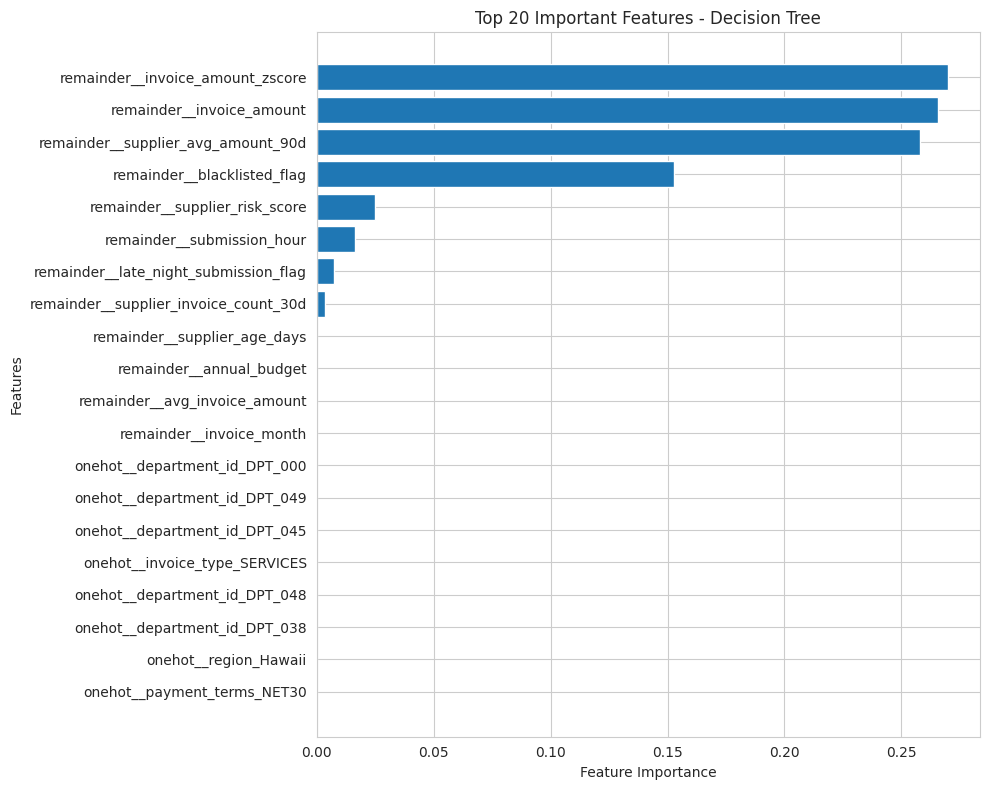

In [ ]:
feature_names = preprocessor.get_feature_names_out()

importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": dt.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,8))

plt.barh(
    importance["Feature"][:20][::-1],
    importance["Importance"][:20][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Top 20 Important Features - Decision Tree")

plt.tight_layout()
plt.show()

#### **CATBOOST Model Implementation**

In [ ]:
!pip install lightgbm catboost -q

In [ ]:
import time
import numpy as np
import pandas as pd

from sklearn.tree import DecisionTreeClassifier

from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [ ]:
X_train_cat = X_train.copy()
X_val_cat = X_val.copy()
X_test_cat = X_test.copy()

In [ ]:
cat_features = [
    "payment_terms",
    "invoice_type",
    "supplier_country",
    "region",
    "department_id"
]

for col in cat_features:
    X_train_cat[col] = X_train_cat[col].astype(str)
    X_val_cat[col] = X_val_cat[col].astype(str)
    X_test_cat[col] = X_test_cat[col].astype(str)

In [ ]:
from catboost import CatBoostClassifier

cat = CatBoostClassifier(
    iterations=300,
    learning_rate=0.1,
    depth=6,
    random_seed=42,
    eval_metric="AUC",
    verbose=100
)

cat.fit(
    X_train_cat,
    y_train,
    cat_features=cat_features,
    eval_set=(X_val_cat, y_val),
    use_best_model=True
)

0:	test: 0.8696310	best: 0.8696310 (0)	total: 370ms	remaining: 1m 50s
100:	test: 0.9629561	best: 0.9629561 (100)	total: 1m 1s	remaining: 2m 1s
200:	test: 0.9636213	best: 0.9636290 (198)	total: 1m 34s	remaining: 46.5s
299:	test: 0.9635729	best: 0.9636664 (289)	total: 2m 6s	remaining: 0us

bestTest = 0.9636664237
bestIteration = 289

Shrink model to first 290 iterations.


CatBoostClassifier(depth=6, eval_metric='AUC', iterations=300, learning_rate=0.1, random_seed=42, verbose=100)

In [ ]:
y_pred_cat = cat.predict(X_test_cat)
y_prob_cat = cat.predict_proba(X_test_cat)[:,1]

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    average_precision_score
)

print("="*60)
print("CatBoost Results")
print("="*60)

print("Accuracy :", accuracy_score(y_test, y_pred_cat))
print("Precision:", precision_score(y_test, y_pred_cat))
print("Recall   :", recall_score(y_test, y_pred_cat))
print("F1 Score :", f1_score(y_test, y_pred_cat))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_cat))
print("PR AUC   :", average_precision_score(y_test, y_prob_cat))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_cat))

print("\nClassification Report")
print(classification_report(y_test, y_pred_cat))

CatBoost Results
Accuracy : 0.9743666666666667
Precision: 0.9691222570532916
Recall   : 0.9153219837157661
F1 Score : 0.9414541301865246
ROC AUC  : 0.962961223564072
PR AUC   : 0.9411599506980802

Confusion Matrix
[[46096   394]
 [ 1144 12366]]

Classification Report
              precision    recall  f1-score   support

           0       0.98      0.99      0.98     46490
           1       0.97      0.92      0.94     13510

    accuracy                           0.97     60000
   macro avg       0.97      0.95      0.96     60000
weighted avg       0.97      0.97      0.97     60000



##### **CONCLUSION :**
**The CatBoost model demonstrated excellent performance in detecting fraudulent procurement invoices, achieving an accuracy of 97.44%, precision of 96.91%, and an F1-score of 94.15%. It also achieved a ROC-AUC of 0.963 and PR-AUC of 0.941, indicating strong discrimination between fraudulent and genuine invoices. With only 394 false positives, CatBoost generated very few false fraud alerts while maintaining high fraud detection capability, making it a reliable and well-balanced model for deploymen**t.

#### **LightGBM Model Implementation**

In [ ]:
!pip install lightgbm -q

In [ ]:
X_train_lgb = X_train.copy()
X_val_lgb = X_val.copy()
X_test_lgb = X_test.copy()

In [ ]:
for col in cat_features:
    X_train_lgb[col] = X_train_lgb[col].astype("category")
    X_val_lgb[col] = X_val_lgb[col].astype("category")
    X_test_lgb[col] = X_test_lgb[col].astype("category")

In [ ]:
print(X_train_lgb[cat_features].dtypes)

payment_terms       category
invoice_type        category
supplier_country    category
region              category
department_id       category
dtype: object


In [ ]:
lgbm = LGBMClassifier(

    objective="binary",

    boosting_type="gbdt",

    n_estimators=300,

    learning_rate=0.1,

    max_depth=6,

    num_leaves=31,

    random_state=42,

    class_weight="balanced",

    n_jobs=-1
)

In [ ]:
lgbm.fit(

    X_train_lgb,

    y_train,

    eval_set=[(X_val_lgb, y_val)],

    eval_metric="auc",

    categorical_feature=cat_features
)

[LightGBM] [Info] Number of positive: 46127, number of negative: 163873
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.137702 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1872
[LightGBM] [Info] Number of data points in the train set: 210000, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


LGBMClassifier(class_weight='balanced', max_depth=6, n_estimators=300,
               n_jobs=-1, objective='binary', random_state=42)

In [ ]:
y_pred_lgbm = lgbm.predict(X_test_lgb)

y_prob_lgbm = lgbm.predict_proba(X_test_lgb)[:,1]

In [ ]:
print("="*60)
print("LightGBM Results")
print("="*60)

print("Accuracy :", accuracy_score(y_test, y_pred_lgbm))
print("Precision:", precision_score(y_test, y_pred_lgbm))
print("Recall   :", recall_score(y_test, y_pred_lgbm))
print("F1 Score :", f1_score(y_test, y_pred_lgbm))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_lgbm))
print("PR AUC   :", average_precision_score(y_test, y_prob_lgbm))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_lgbm))

print("\nClassification Report")
print(classification_report(y_test, y_pred_lgbm))

LightGBM Results
Accuracy : 0.9670166666666666
Precision: 0.9238403293391164
Recall   : 0.93019985196151
F1 Score : 0.9270091837863755
ROC AUC  : 0.962597129760083
PR AUC   : 0.9399432120922313

Confusion Matrix
[[45454  1036]
 [  943 12567]]

Classification Report
              precision    recall  f1-score   support

           0       0.98      0.98      0.98     46490
           1       0.92      0.93      0.93     13510

    accuracy                           0.97     60000
   macro avg       0.95      0.95      0.95     60000
weighted avg       0.97      0.97      0.97     60000



* **Feature Importance**

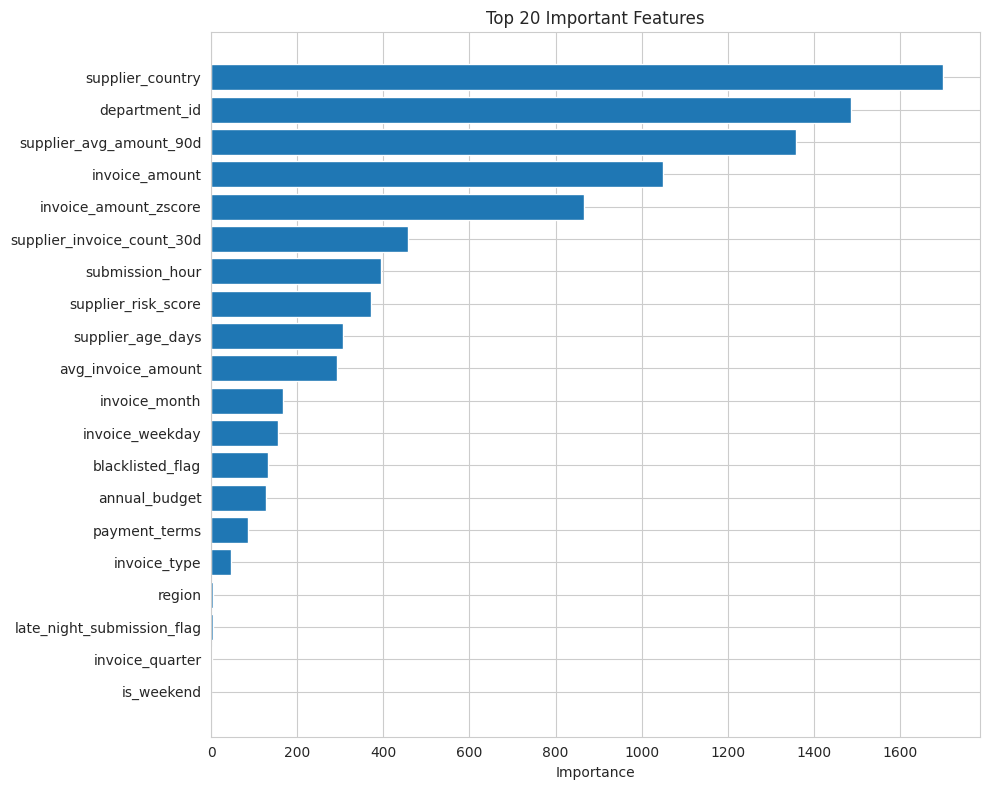

In [ ]:
importance = pd.DataFrame({

    "Feature": X_train_lgb.columns,

    "Importance": lgbm.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,8))

plt.barh(
    importance["Feature"][:20][::-1],
    importance["Importance"][:20][::-1]
)

plt.title("Top 20 Important Features")

plt.xlabel("Importance")

plt.tight_layout()

plt.show()

#####  **CONCLUSION :**

**The LightGBM model also delivered strong classification performance, achieving an accuracy of 96.70%, recall of 93.02%, and an ROC-AUC of 0.963. It successfully detected a slightly higher number of fraudulent invoices than CatBoost, as reflected by its higher recall. However, it produced 1,036 false positives, resulting in more genuine invoices being incorrectly flagged as fraudulent. Overall, LightGBM is an effective model for fraud detection, particularly when maximizing fraud detection is the primary objective, though it requires a higher manual verification effort compared to CatBoost.**